Import Library

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [4]:
#load data

df = pd.read_csv("datasets/processed_flight_data.csv")  

Pisah Fitur X dan Y

In [5]:
#pisah fitur (x) dan target(y), target = price
X = df[['duration', 'class_Economy', 'days_left',
        'stops_zero', 'stops_two_or_more',
        'airline_Vistara', 'airline_Indigo', 'airline_GO_FIRST', 'airline_SpiceJet']]
Y = df['price']

Bagi data menjadi 2 (Train dan Test)

In [7]:
#split data jadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


Buat model regresi

In [8]:
# model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

# Nilai error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 47285365.546835594
R2 Score: 0.908231945652773


Melihat Koefisiennya

In [10]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                    Coefficient
duration             327.198606
class_Economy     -44932.449196
days_left          -1760.973730
stops_zero         -7874.640450
stops_two_or_more   2447.365080
airline_Vistara     4001.385217
airline_Indigo      2196.083750
airline_GO_FIRST    1577.736519
airline_SpiceJet    2565.043399


Evaluasi model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediksi data test
y_pred = model.predict(X_test)

# Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 4609.5534277152055
RMSE: 6876.435526261815
R²  : 0.908231945652773


Analisis error

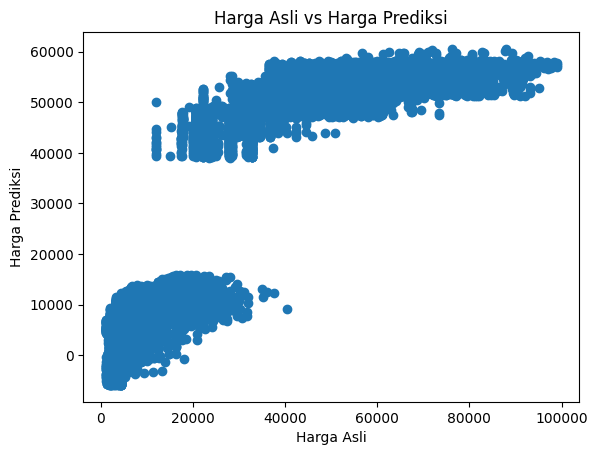

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.title("Harga Asli vs Harga Prediksi")
plt.show()


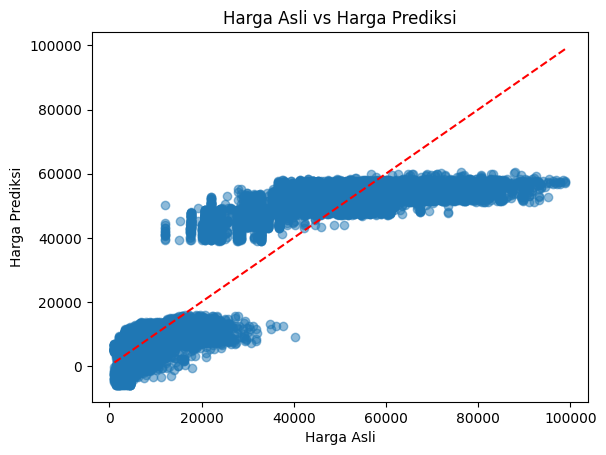

In [13]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # garis ideal
plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.title("Harga Asli vs Harga Prediksi")
plt.show()


data yang errornya paling besar

In [14]:
error = abs(y_test - y_pred)
print(df.loc[error.sort_values(ascending=False).index[:5]])  # lihat 5 prediksi paling meleset

        duration  days_left  price  airline_Air_India  airline_GO_FIRST  \
272231  0.930549   1.104136  95183                  0                 0   
288498  0.490174  -1.405158  98912                  0                 0   
288377  0.693204  -1.552764  98912                  0                 0   
291101  0.608847   1.546953  93200                  0                 0   
251085  1.955707  -1.552764  98919                  0                 0   

        airline_Indigo  airline_SpiceJet  airline_Vistara  \
272231               0                 0                1   
288498               0                 0                1   
288377               0                 0                1   
291101               0                 0                1   
251085               0                 0                1   

        source_city_Chennai  source_city_Delhi  ...  arrival_time_Evening  \
272231                    0                  0  ...                     0   
288498                    1 

Simpan Model

In [15]:
import joblib

# Simpan model
joblib.dump(model, 'flight_price_model.pkl')

['flight_price_model.pkl']